## Previsão de Tendência do IBOVESPA

### Objetivo do Projeto

Desenvolver um modelo preditivo capaz de prever se o índice **IBOVESPA** vai fechar em **alta (↑)** ou **baixa (↓)** no dia seguinte, com base em dados históricos do próprio índice.

O modelo deve atingir **acurácia mínima de 75%** no conjunto de teste (últimos 30 dias de dados disponíveis).

### 1. Importação de bibliotecas

In [32]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Pré-processamento 
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas de avaliação 
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Utilidades
import unicodedata
from pathlib import Path

### 2. Coleta e carregamento dos dados
#### Fonte dos dados

Os dados históricos do IBOVESPA foram obtidos em: [https://br.investing.com/indices/bovespa-historical-data](https://br.investing.com/indices/bovespa-historical-data)

- **Período selecionado:** Janeiro/2024 a Março/2026
- **Frequência:** Diária
- **Arquivo:** `IBOVESPA_historicos_012024_032026.csv`

In [33]:
# Carregamento do CSV exportado do investing.com
# Colunas esperadas: Data, Último, Abertura, Máxima, Mínima, Vol., Var%

RAW_PATH = Path("../data/raw")
file_name = "IBOVESPA_historicos_012020_032026.csv"

df = pd.read_csv(
    RAW_PATH / file_name,
    thousands='.',     # separador de milhar é ponto no formato brasileiro
    decimal=',',       # separador decimal é vírgula
    parse_dates=['Data'],
    dayfirst=True      # datas no formato DD.MM.YYYY
)

print(f'Dados carregados: {df.shape[0]} linhas e {df.shape[1]} colunas')
df.head()

Dados carregados: 1548 linhas e 7 colunas


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2026-03-19,180180,179624,181251,176296,"11,49M","0,30%"
1,2026-03-18,179640,180409,181551,179576,"9,75B","-0,43%"
2,2026-03-17,180410,179882,182800,179850,"9,33B","0,30%"
3,2026-03-16,179875,177656,181255,177656,"7,37B","1,25%"
4,2026-03-13,177653,179285,180996,177322,"9,53B","-0,91%"


In [34]:
# Padronização dos nomes das colunas
# Renomeamos para nomes sem acento

df.rename(columns={
    'Último':   'fechamento',
    'Abertura': 'abertura',
    'Máxima':   'maxima',
    'Mínima':   'minima',
    'Vol.':     'volume',
    'Var%':     'variacao_pct',
    'Data':     'data'
}, inplace=True)

# Ordenar do mais antigo para o mais recente - Obrigatório em séries temporais
df.sort_values('data', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Período: {df["data"].min().date()} até {df["data"].max().date()}')
df.head()

Período: 2020-01-02 até 2026-03-19


,data,fechamento,abertura,maxima,minima,volume,variacao_pct
0,2020-01-02,118573,115652,118573,115649,"5,16M","2,53%"
1,2020-01-03,117707,118564,118792,117341,"6,83M","-0,73%"
2,2020-01-06,116878,117707,117707,116269,"6,57M","-0,70%"
3,2020-01-07,116662,116872,117076,115965,"4,85M","-0,18%"
4,2020-01-08,116247,116667,117335,115693,"5,91M","-0,36%"


### 3. Análise Exploratória (EDA)
EDA responde três perguntas fundamentais:
- Os dados estão completos e consistentes?
- Qual é o comportamento histórico do índice?
- Existem padrões ou anomalias relevantes?

In [35]:
# Visão geral: tipos, nulos e estatísticas
print('Tipos de dados')
print(df.dtypes)
print()
print('Valores ausentes')
print(df.isnull().sum())
print()
print('Estatísticas descritivas')
df.describe()

Tipos de dados
data            datetime64[us]
fechamento               int64
abertura                 int64
maxima                   int64
minima                   int64
volume                     str
variacao_pct               str
dtype: object

Valores ausentes
data            0
fechamento      0
abertura        0
maxima          0
minima          0
volume          0
variacao_pct    0
dtype: int64

Estatísticas descritivas


,data,fechamento,abertura,maxima,minima
count,1548,1548.000000,1548.000000,1548.000000,1548.000000
mean,2023-02-09 20:48:22.325581,119738.009690,119696.855943,120724.133721,118719.109819
min,2020-01-02 00:00:00,63570.000000,63604.000000,67604.000000,61691.000000
25%,2021-07-25 06:00:00,108564.250000,108563.000000,109749.750000,107514.250000
50%,2023-02-08 12:00:00,118157.500000,118141.500000,118962.000000,117250.000000
75%,2024-08-28 06:00:00,128340.250000,128320.750000,129267.750000,127657.000000
max,2026-03-19 00:00:00,191490.000000,191491.000000,192624.000000,190419.000000
std,NaN,18921.837942,18859.778080,18798.688274,18980.364000


In [36]:
# Tratamento da coluna Volume
# O volume vem como string - ex: '12,5B' (bilhões) ou '850M' (milhões)

def converter_volume(v):
    """Converte strings de volume (ex: '12,5B', '850M') para float."""
    if pd.isna(v) or v == '-':
        return np.nan
    v = str(v).replace(',', '.')
    if 'B' in v:
        return float(v.replace('B', '')) * 1e9
    elif 'M' in v:
        return float(v.replace('M', '')) * 1e6
    elif 'K' in v:
        return float(v.replace('K', '')) * 1e3
    return float(v)

df['volume'] = df['volume'].apply(converter_volume)

In [37]:
# Remover '%' da coluna variacao_pct e converter para float
df['variacao_pct'] = (
    df['variacao_pct']
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df.dtypes

data            datetime64[us]
fechamento               int64
abertura                 int64
maxima                   int64
minima                   int64
volume                 float64
variacao_pct           float64
dtype: object

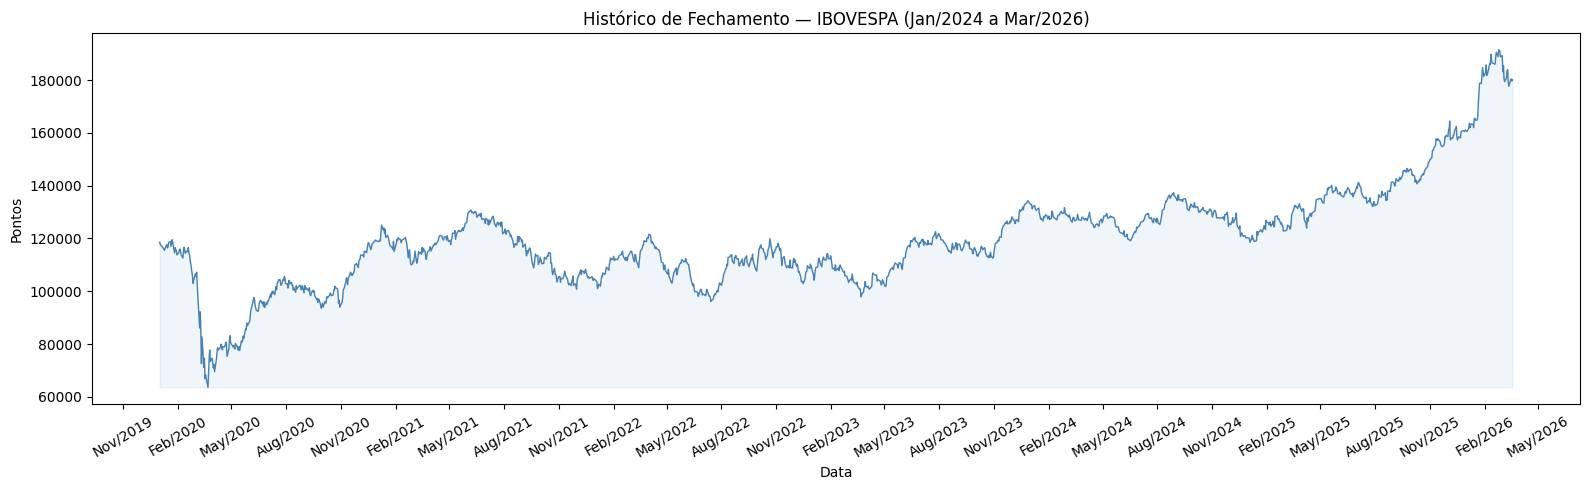

In [38]:
# Visualização 1: Série histórica de fechamento

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['data'], df['fechamento'], color='steelblue', linewidth=1)
ax.fill_between(df['data'], df['fechamento'], df['fechamento'].min(),
                alpha=0.08, color='steelblue')
ax.set_title('Histórico de Fechamento — IBOVESPA (Jan/2024 a Mar/2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Pontos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

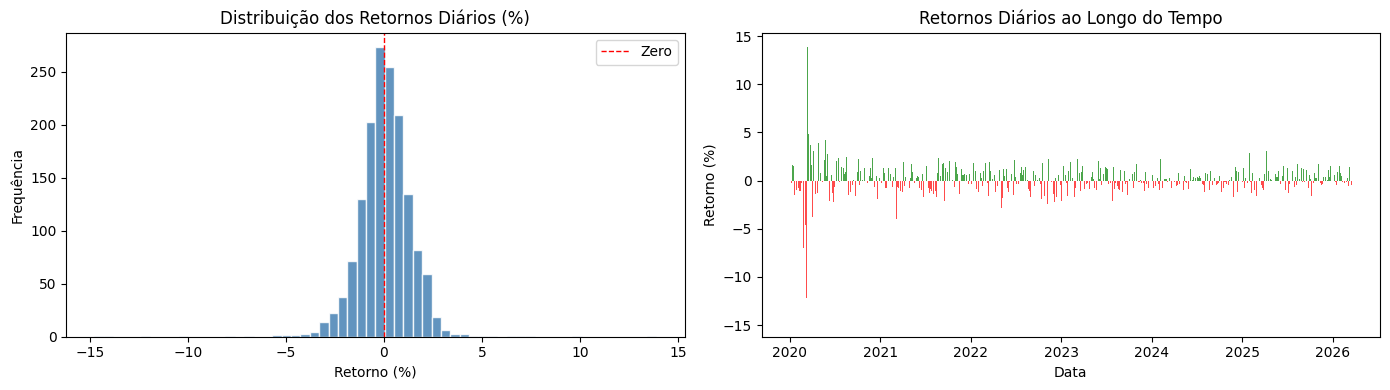

Retorno médio diário : 0.0388%
Desvio padrão        : 1.5250%
Maior alta em 1 dia  : 13.91%
Maior queda em 1 dia : -14.78%


In [39]:
# Visualização 2: Retornos diários

retorno = df['fechamento'].pct_change() * 100  # variação percentual em %

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(retorno.dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='Zero')
axes[0].set_title('Distribuição dos Retornos Diários (%)')
axes[0].set_xlabel('Retorno (%)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Série temporal colorida: verde = dia positivo, vermelho = dia negativo
cores_ret = ['green' if r >= 0 else 'red' for r in retorno.fillna(0)]
axes[1].bar(df['data'], retorno.fillna(0), color=cores_ret, alpha=0.7, width=1)
axes[1].set_title('Retornos Diários ao Longo do Tempo')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Retorno (%)')

plt.tight_layout()
plt.show()

print(f'Retorno médio diário : {retorno.mean():.4f}%')
print(f'Desvio padrão        : {retorno.std():.4f}%')
print(f'Maior alta em 1 dia  : {retorno.max():.2f}%')
print(f'Maior queda em 1 dia : {retorno.min():.2f}%')

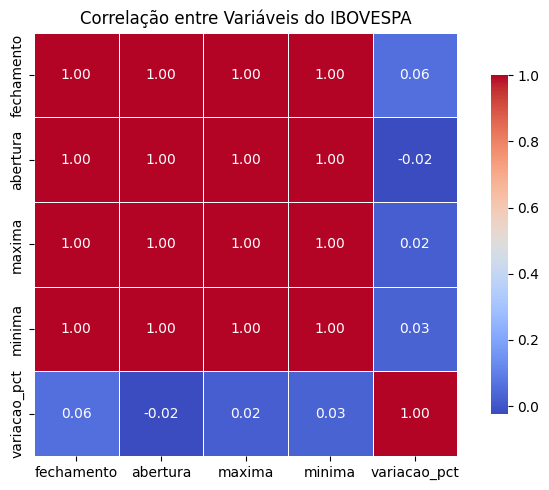

In [40]:
# Visualização 3: Mapa de correlação entre variáveis

colunas_num = ['fechamento', 'abertura', 'maxima', 'minima', 'variacao_pct']
corr = df[colunas_num].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlação entre Variáveis do IBOVESPA')
plt.tight_layout()
plt.show()

### 4. Engenharia de Atributos (Feature Engineering)
Aqui criamos as variáveis (features) que os modelos vão usar para identificar padrões.

Como o IBOVESPA é uma **série temporal**, aplicamos **janelas deslizantes** (lagged features):
    usamos apenas informações do **passado** para gerar cada feature, evitando vazamento de dados (data leakage).

#### Estratégia de features adotada:

| Grupo | Features | Objetivo |
|---|---|---|
| Retornos lagged | retorno_1d a retorno_10d | Capturar momentum de curto prazo |
| Médias móveis | MM5, MM10, MM20 + distâncias | Identificar tendência |
| Volatilidade | std 5 e 10 dias | Medir incerteza do mercado |
| Intraday | amplitude, posição no range | Força compradora/vendedora no dia |

Distribuição do target (1 = Alta, 0 = Baixa):
target
1    802
0    746
Name: count, dtype: int64

Alta (1):  51.8% dos pregões
Baixa (0): 48.2% dos pregões


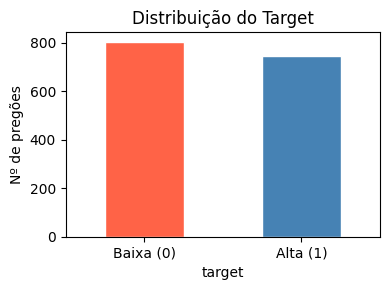

In [41]:
# 4.1 Variável TARGET
# Target = 1 → fechamento de AMANHÃ > fechamento de HOJE (ALTA)
# Target = 0 → fechamento de AMANHÃ ≤ fechamento de HOJE (BAIXA)
# shift(-1) "traz" o fechamento do próximo dia para a linha atual

df['target'] = (df['fechamento'].shift(-1) > df['fechamento']).astype(int)

print('Distribuição do target (1 = Alta, 0 = Baixa):')
vc = df['target'].value_counts()
print(vc)
print()
print(f'Alta (1):  {df["target"].mean()*100:.1f}% dos pregões')
print(f'Baixa (0): {(1-df["target"].mean())*100:.1f}% dos pregões')

fig, ax = plt.subplots(figsize=(4, 3))
vc.plot(kind='bar', ax=ax, color=['tomato', 'steelblue'], edgecolor='white', rot=0)
ax.set_xticklabels(['Baixa (0)', 'Alta (1)'])
ax.set_title('Distribuição do Target')
ax.set_ylabel('Nº de pregões')
plt.tight_layout()
plt.show()

In [42]:
# 4.2 Retornos lagged
# pct_change(n) = variação entre o dia atual e N dias atrás
# Já são valores do passado → sem risco de data leakage

df['retorno_1d']  = df['fechamento'].pct_change(1)
df['retorno_2d']  = df['fechamento'].pct_change(2)
df['retorno_3d']  = df['fechamento'].pct_change(3)
df['retorno_5d']  = df['fechamento'].pct_change(5)   # aprox. 1 semana de pregão
df['retorno_10d'] = df['fechamento'].pct_change(10)  # aprox. 2 semanas

In [43]:
# 4.3 Médias Móveis e distâncias
# A média móvel suaviza o ruído e revela a direção do mercado

df['mm5']  = df['fechamento'].rolling(5).mean()
df['mm10'] = df['fechamento'].rolling(10).mean()
df['mm20'] = df['fechamento'].rolling(20).mean()

# Distância relativa: positivo = preço acima da média (força)
#                     negativo = preço abaixo da média (fraqueza)
df['dist_mm5']  = (df['fechamento'] - df['mm5'])  / df['mm5']
df['dist_mm10'] = (df['fechamento'] - df['mm10']) / df['mm10']
df['dist_mm20'] = (df['fechamento'] - df['mm20']) / df['mm20']

In [44]:
# 4.4 Volatilidade histórica
# Desvio padrão dos retornos em janelas de 5 e 10 dias
# Alta volatilidade = mercado mais instável e imprevisível

df['volatilidade_5d']  = df['retorno_1d'].rolling(5).std()
df['volatilidade_10d'] = df['retorno_1d'].rolling(10).std()

In [45]:
# 4.5 Análise intraday

# Amplitude: variação entre máxima e mínima relativa ao fechamento
df['amplitude'] = (df['maxima'] - df['minima']) / df['fechamento']

# Posição no range: onde o preço fechou dentro da variação do dia
# 1.0 = fechou na máxima (compradores dominaram o dia)
# 0.0 = fechou na mínima (vendedores dominaram o dia)
df['posicao_no_range'] = (
    (df['fechamento'] - df['minima']) /
    (df['maxima'] - df['minima'] + 1e-9)  # +1e-9 evita divisão por zero
)

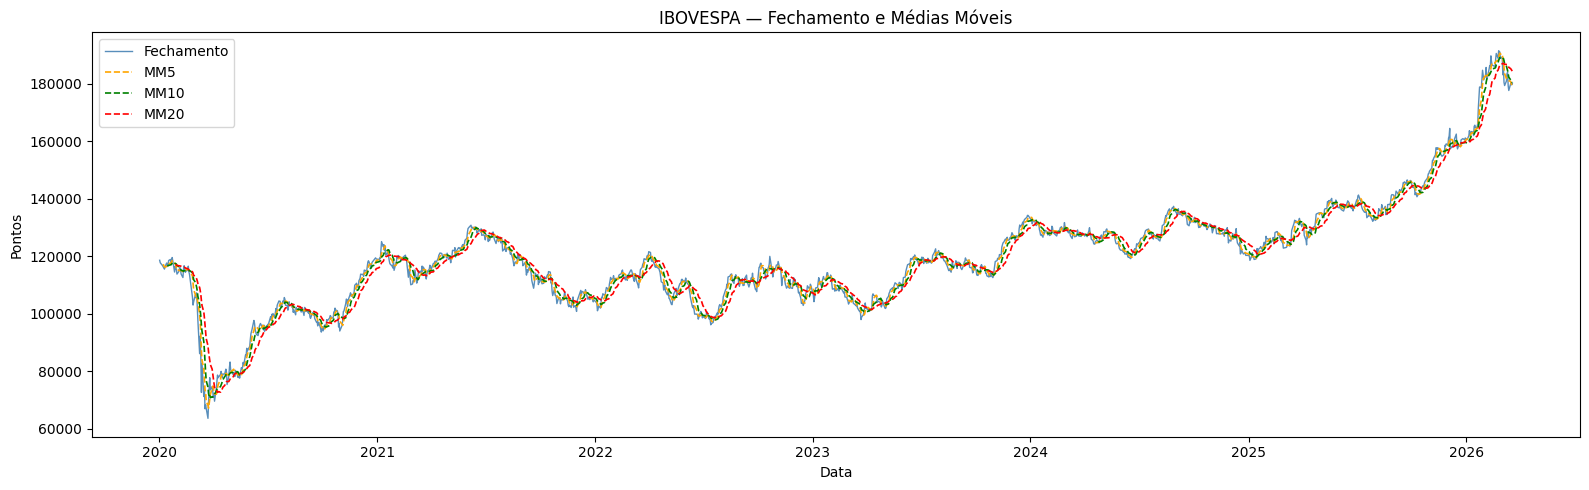

In [46]:
# 4.6 Visualização: Médias Móveis sobre o fechamento

plt.figure(figsize=(16, 5))
plt.plot(df['data'], df['fechamento'], label='Fechamento',
         color='steelblue', linewidth=1, alpha=0.9)
plt.plot(df['data'], df['mm5'],  label='MM5',  color='orange',
         linewidth=1.2, linestyle='--')
plt.plot(df['data'], df['mm10'], label='MM10', color='green',
         linewidth=1.2, linestyle='--')
plt.plot(df['data'], df['mm20'], label='MM20', color='red',
         linewidth=1.2, linestyle='--')
plt.title('IBOVESPA — Fechamento e Médias Móveis')
plt.xlabel('Data')
plt.ylabel('Pontos')
plt.legend()
plt.tight_layout()
plt.show()

### 5. Preparação para modelagem (target + divisão treino/teste)

#### Divisão Treino / Teste

- O modelo só pode aprender com o **passado** e ser testado no **futuro**.
- Qualquer mistura temporal contamina o modelo e infla artificialmente a acurácia (data leakage).

In [47]:
# Lista de features usadas nos modelos
FEATURES = [
    # Retornos lagged (memória de curto prazo)
    'retorno_1d', 'retorno_2d', 'retorno_3d', 'retorno_5d', 'retorno_10d',
    # Posição relativa às médias móveis (tendência)
    'dist_mm5', 'dist_mm10', 'dist_mm20',
    # Risco/incerteza
    'volatilidade_5d', 'volatilidade_10d',
    # Comportamento intraday
    'amplitude', 'posicao_no_range'
]

TARGET = 'target'

# Remover linhas com NaN (geradas pelas janelas deslizantes e pelo target)
df_model = df[FEATURES + [TARGET, 'data']].dropna().copy()

print(f'Registros após limpeza : {len(df_model)}')
print(f'Período                : {df_model["data"].min().date()} → {df_model["data"].max().date()}')

Registros após limpeza : 1529
Período                : 2020-01-29 → 2026-03-19


In [48]:
# Divisão temporal
# TREINO: todos os dados exceto os últimos 30 dias
# TESTE : últimos 30 dias (conforme exigência do briefing)

DIAS_TESTE = 30

df_treino = df_model.iloc[:-DIAS_TESTE]
df_teste  = df_model.iloc[-DIAS_TESTE:]

X_treino = df_treino[FEATURES]
y_treino = df_treino[TARGET]
X_teste  = df_teste[FEATURES]
y_teste  = df_teste[TARGET]

print(f'Treino : {len(df_treino):>4} dias | {df_treino["data"].min().date()} → {df_treino["data"].max().date()}')
print(f'Teste  : {len(df_teste):>4} dias | {df_teste["data"].min().date()}  → {df_teste["data"].max().date()}')
print()
print('Distribuição do target:')
print(pd.DataFrame({
    'Treino': y_treino.value_counts(normalize=True).round(3),
    'Teste' : y_teste.value_counts(normalize=True).round(3)
}))

Treino : 1499 dias | 2020-01-29 → 2026-02-03
Teste  :   30 dias | 2026-02-04  → 2026-03-19

Distribuição do target:
        Treino  Teste
target               
1         0.52    0.5
0         0.48    0.5


In [49]:
# Normalização para Regressão Logística
# StandardScaler: escala para média 0 e desvio padrão 1
# CRÍTICO: fit() APENAS no treino → evita data leakage do futuro!

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)  # aprende a escala do treino
X_teste_scaled  = scaler.transform(X_teste)       # aplica a mesma escala no teste

### 6. Modelagem - Regressão Logística (baseline)
A Regressão Logística é o nosso **modelo baseline**, o ponto de referência para avaliar se modelos mais complexos realmente agregam valor.

**Vantagens:**
- Alta interpretabilidade - coeficientes mostram o peso de cada feature
- Baixíssimo risco de overfitting
- Simples de explicar para analistas e stakeholders não técnicos

In [50]:
# Treinamento
# max_iter=1000: garante que o algoritmo de otimização vai convergir

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_treino_scaled, y_treino)

y_pred_lr   = lr_model.predict(X_teste_scaled)
acuracia_lr = accuracy_score(y_teste, y_pred_lr)

print(f'Acurácia — Regressão Logística: {acuracia_lr*100:.2f}%')
print()
print(classification_report(y_teste, y_pred_lr, target_names=['Baixa', 'Alta']))

Acurácia — Regressão Logística: 40.00%

              precision    recall  f1-score   support

       Baixa       0.33      0.20      0.25        15
        Alta       0.43      0.60      0.50        15

    accuracy                           0.40        30
   macro avg       0.38      0.40      0.38        30
weighted avg       0.38      0.40      0.38        30



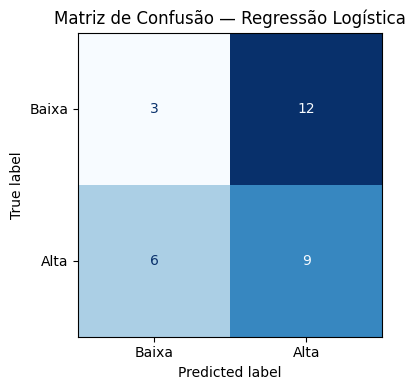

In [51]:
# Matriz de Confusão
# Linhas = valores reais | Colunas = valores previstos
# Diagonal principal = acertos (Verdadeiro Positivo e Verdadeiro Negativo)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_teste, y_pred_lr),
    display_labels=['Baixa', 'Alta']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Regressão Logística')
plt.tight_layout()
plt.show()

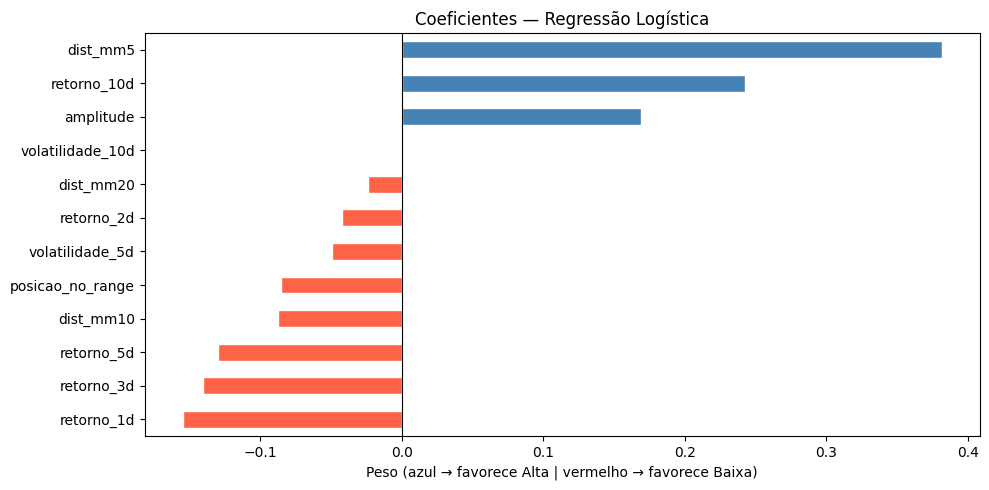

In [52]:
# Coeficientes: o "peso" de cada feature na decisão
# Positivo = feature favorece a previsão de ALTA
# Negativo = feature favorece a previsão de BAIXA

coefs = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()

plt.figure(figsize=(10, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coefs]
coefs.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regressão Logística')
plt.xlabel('Peso (azul → favorece Alta | vermelho → favorece Baixa)')
plt.tight_layout()
plt.show()

### 7. Modelagem - Random Forest
O Random Forest é um **ensemble** de árvores de decisão treinadas em subconjuntos aleatórios dos dados.
A predição final é feita por **votação majoritária** entre todas as árvores.

**Vantagens:**
- Captura **relações não-lineares** entre features (o que a regressão logística não faz)
- Robusto a outliers e não exige normalização
- Fornece **importância das features** para enriquecer o storytelling
- Controle de overfitting via `max_depth` e `min_samples_leaf`

In [53]:
# Treinamento
# n_estimators=300 : usa 300 árvores — mais árvores = mais estável
# max_depth=5       : limita profundidade → evita overfitting
# min_samples_leaf=10: folha precisa de ≥ 10 amostras → generaliza melhor
# n_jobs=-1         : usa todos os núcleos disponíveis

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_treino, y_treino)  # RF não precisa de normalização

y_pred_rf   = rf_model.predict(X_teste)
acuracia_rf = accuracy_score(y_teste, y_pred_rf)

print(f'Acurácia — Random Forest: {acuracia_rf*100:.2f}%')
print()
print(classification_report(y_teste, y_pred_rf, target_names=['Baixa', 'Alta']))

Acurácia — Random Forest: 53.33%

              precision    recall  f1-score   support

       Baixa       0.55      0.40      0.46        15
        Alta       0.53      0.67      0.59        15

    accuracy                           0.53        30
   macro avg       0.54      0.53      0.52        30
weighted avg       0.54      0.53      0.52        30



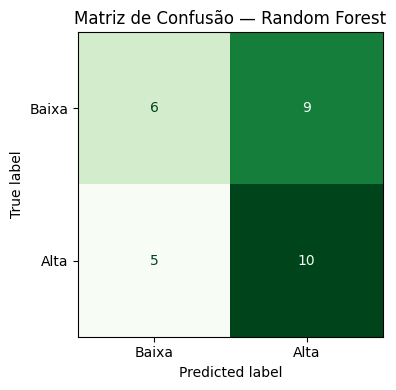

In [54]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_teste, y_pred_rf),
    display_labels=['Baixa', 'Alta']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.show()

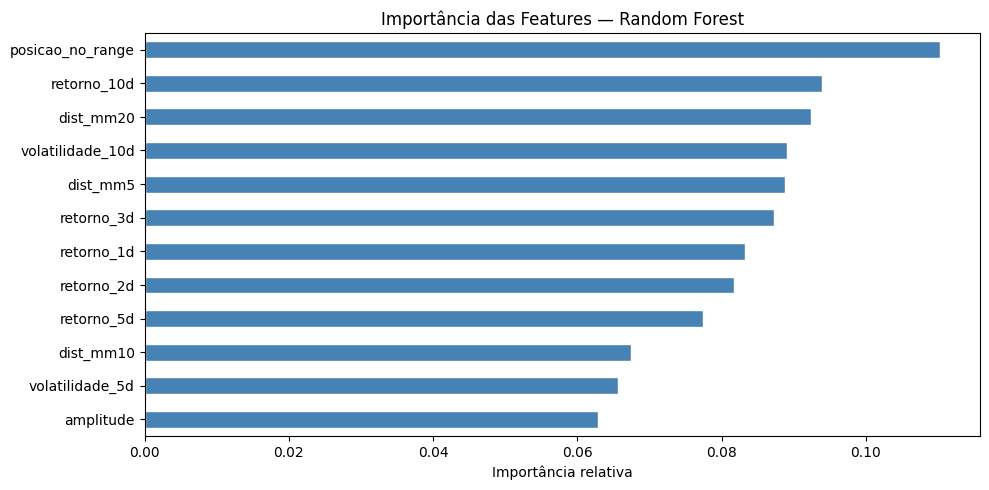

Top 5 features mais importantes:
posicao_no_range    0.110308
retorno_10d         0.093937
dist_mm20           0.092402
volatilidade_10d    0.089091
dist_mm5            0.088817
dtype: float64


In [55]:
# Importância das Features
# Mede a contribuição de cada variável para reduzir a impureza nas árvores

importances_rf = pd.Series(
    rf_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importances_rf.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

print('Top 5 features mais importantes:')
print(importances_rf.sort_values(ascending=False).head())

### 8. Modelagem - Gradient Boosting (XGBoost)
O XGBoost (Extreme Gradient Boosting) é um algoritmo de **boosting sequencial** — diferente do Random Forest (paralelo), cada nova árvore **corrige os erros da anterior**, tornando o modelo progressivamente mais preciso.

**Vantagens:**
- Geralmente obtém a **maior acurácia** entre os três modelos
- Regularização nativa (`subsample`, `colsample_bytree`) que controla overfitting
- Amplamente utilizado em competições de Data Science e no mercado financeiro

**Trade-off:** é o modelo mais complexo de interpretar e mais sensível aos hiperparâmetros.

In [56]:
# Treinamento
# n_estimators=300   : número de árvores boosted
# max_depth=4        : menor que RF para compensar o efeito cumulativo do boosting
# learning_rate=0.05 : passo pequeno → aprendizado mais gradual e estável
# subsample=0.8      : usa 80% das linhas por árvore → reduz overfitting
# colsample_bytree=0.8: usa 80% das features por árvore → mais diversidade

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_treino, y_treino)

y_pred_xgb   = xgb_model.predict(X_teste)
acuracia_xgb = accuracy_score(y_teste, y_pred_xgb)

print(f'Acurácia — XGBoost: {acuracia_xgb*100:.2f}%')
print()
print(classification_report(y_teste, y_pred_xgb, target_names=['Baixa', 'Alta']))

/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:00:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Acurácia — XGBoost: 50.00%

              precision    recall  f1-score   support

       Baixa       0.50      0.40      0.44        15
        Alta       0.50      0.60      0.55        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.49        30



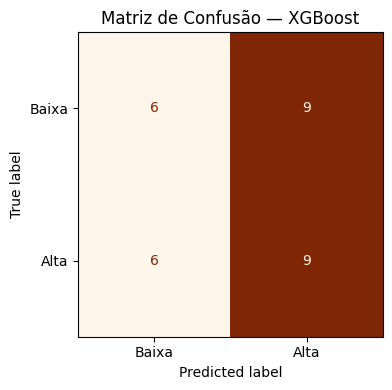

In [57]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_teste, y_pred_xgb),
    display_labels=['Baixa', 'Alta']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusão — XGBoost')
plt.tight_layout()
plt.show()

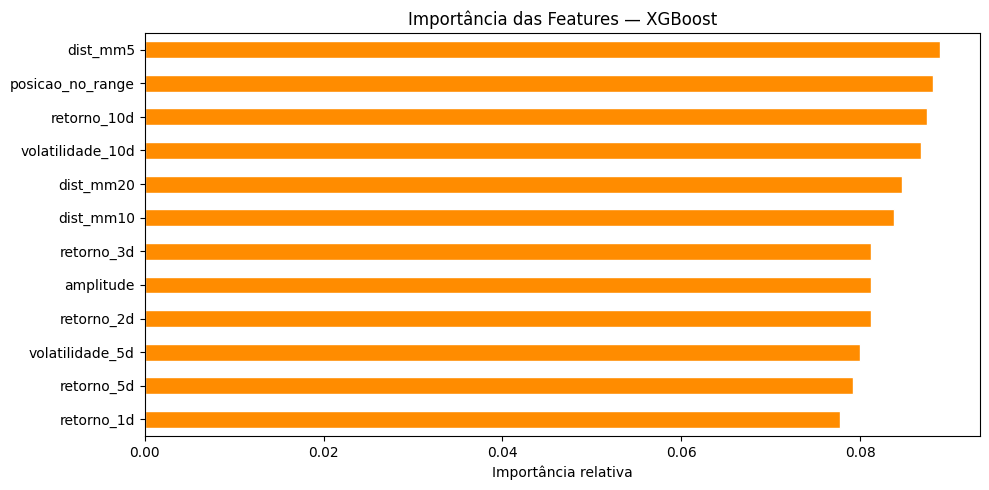

Top 5 features mais importantes:
dist_mm5            0.088923
posicao_no_range    0.088103
retorno_10d         0.087404
volatilidade_10d    0.086795
dist_mm20           0.084628
dtype: float32


In [58]:
# Importância das Features (XGBoost)

importances_xgb = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importances_xgb.plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('Importância das Features — XGBoost')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

print('Top 5 features mais importantes:')
print(importances_xgb.sort_values(ascending=False).head())

### 9. Comparação de modelos e escolha final

             Modelo  Acurácia (%) Meta ≥75%
Regressão Logística         40.00         ❌
      Random Forest         53.33         ❌
            XGBoost         50.00         ❌


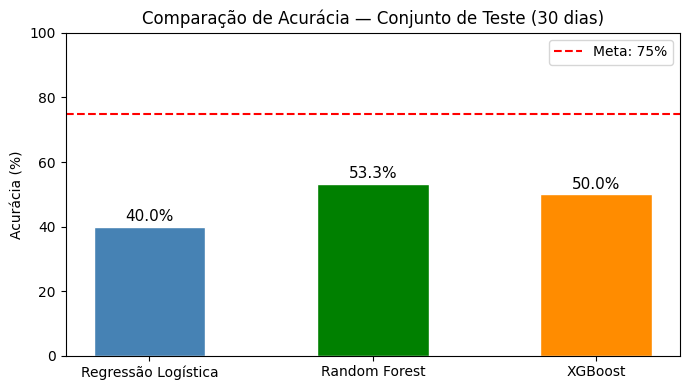

In [59]:
# Tabela comparativa dos três modelos

resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'Acurácia (%)': [
        round(acuracia_lr  * 100, 2),
        round(acuracia_rf  * 100, 2),
        round(acuracia_xgb * 100, 2)
    ],
    'Meta ≥75%': [
        '✅' if acuracia_lr  >= 0.75 else '❌',
        '✅' if acuracia_rf  >= 0.75 else '❌',
        '✅' if acuracia_xgb >= 0.75 else '❌'
    ]
})

print(resultados.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    resultados['Modelo'],
    resultados['Acurácia (%)'],
    color=['steelblue', 'green', 'darkorange'],
    edgecolor='white', width=0.5
)
ax.axhline(75, color='red', linestyle='--', linewidth=1.5, label='Meta: 75%')
ax.set_ylim(0, 100)
ax.set_ylabel('Acurácia (%)')
ax.set_title('Comparação de Acurácia — Conjunto de Teste (30 dias)')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

In [60]:
# Seleção automática do modelo com maior acurácia

acuracias = {
    'Regressão Logística': acuracia_lr,
    'Random Forest'      : acuracia_rf,
    'XGBoost'            : acuracia_xgb
}
preds = {
    'Regressão Logística': y_pred_lr,
    'Random Forest'      : y_pred_rf,
    'XGBoost'            : y_pred_xgb
}

melhor_modelo   = max(acuracias, key=acuracias.get)
melhor_acuracia = acuracias[melhor_modelo]
y_pred_final    = preds[melhor_modelo]

print(f'🏆 Modelo selecionado : {melhor_modelo}')
print(f'   Acurácia no teste  : {melhor_acuracia*100:.2f}%')

🏆 Modelo selecionado : Random Forest
   Acurácia no teste  : 53.33%


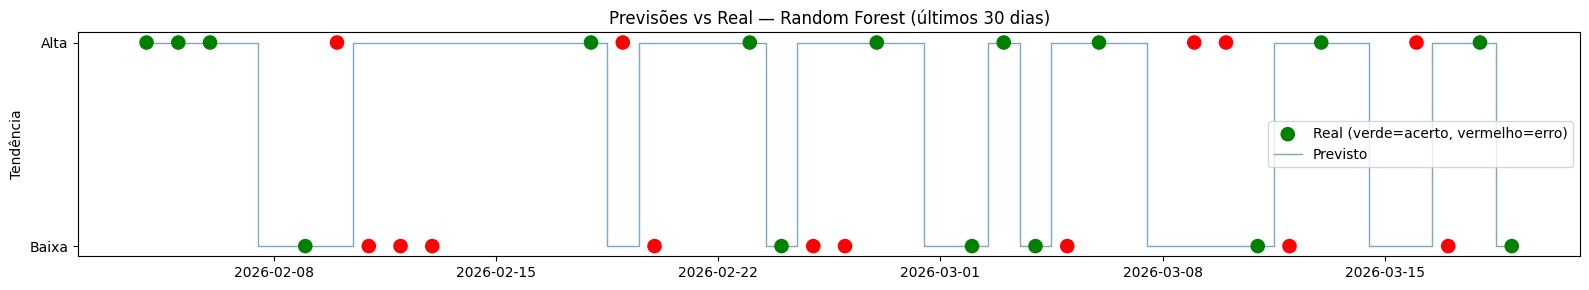

Acertos: 16 de 30 dias (53.3%)


In [61]:
# Gráfico: Previsões vs Real — últimos 30 dias

df_resultado = df_teste[['data']].copy()
df_resultado['real']     = y_teste.values
df_resultado['previsto'] = y_pred_final
df_resultado['acerto']   = (df_resultado['real'] == df_resultado['previsto'])

fig, ax = plt.subplots(figsize=(16, 3))
cores = df_resultado['acerto'].map({True: 'green', False: 'red'})
ax.scatter(df_resultado['data'], df_resultado['real'],
           c=cores, s=90, zorder=5, label='Real (verde=acerto, vermelho=erro)')
ax.step(df_resultado['data'], df_resultado['previsto'],
        color='steelblue', linewidth=1, alpha=0.7, where='mid', label='Previsto')
ax.set_title(f'Previsões vs Real — {melhor_modelo} (últimos 30 dias)')
ax.set_ylabel('Tendência')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Baixa', 'Alta'])
ax.legend()
plt.tight_layout()
plt.show()

acertos = df_resultado['acerto'].sum()
total   = len(df_resultado)
print(f'Acertos: {acertos} de {total} dias ({acertos/total*100:.1f}%)')

### 10. Justificativa técnica
#### Comparação dos modelos

| Critério | Regressão Logística | Random Forest | XGBoost |
|---|---|---|---|
| Interpretabilidade | ⭐⭐⭐ Alta | ⭐⭐ Média | ⭐ Baixa |
| Captura não-linearidades | ❌ | ✅ | ✅ |
| Risco de overfitting | 🟢 Baixo | 🟡 Médio | 🟡 Médio |
| Necessidade de normalização | ✅ Sim | ❌ Não | ❌ Não |
| Complexidade de ajuste | Simples | Média | Alta |

#### Como tratamos a natureza sequencial dos dados

1. **Janelas deslizantes (lagged features):** retornos de 1 a 10 dias capturam memória de curto prazo sem vazar dados futuros
2. **Médias móveis:** contexto de tendência de médio prazo (5, 10 e 20 dias)
3. **Divisão temporal rigorosa:** teste = últimos 30 dias, treino = todo o restante anterior
4. **Scaler ajustado apenas no treino:** evita que a escala do futuro contamine o modelo

#### Trade-offs Acurácia vs Overfitting

- **Regressão Logística:** baseline estável, mas limitada a padrões lineares
- **Random Forest:** `max_depth=5` e `min_samples_leaf=10` evitam árvores que "decoram" o treino
- **XGBoost:** `learning_rate=0.05` (passo pequeno) + `subsample=0.8` + `colsample_bytree=0.8` → regularização nativa

> 💡 Em séries financeiras, overfitting é o maior inimigo. Um modelo que acerta 65% no treino e 78% no teste é **muito melhor** do que um que acerta 95% no treino e 62% no teste.

### 11. Conclusão

In [62]:
# Resumo final automatizado

print('=' * 65)
print('           RESUMO FINAL')
print('=' * 65)
print()
print(f'  Arquivo   : IBOVESPA_historicos_012024_032026.csv')
print(f'  Período   : {df_model["data"].min().date()} a {df_model["data"].max().date()}')
print(f'  Registros : {len(df_model)} pregões')
print(f'  Features  : {len(FEATURES)}')
print()
print('  Resultados no conjunto de teste (últimos 30 dias):')
print(f'    • Regressão Logística : {acuracia_lr*100:.2f}%')
print(f'    • Random Forest       : {acuracia_rf*100:.2f}%')
print(f'    • XGBoost             : {acuracia_xgb*100:.2f}%')
print()
print(f'  🏆 Modelo selecionado  : {melhor_modelo}')
print(f'  📊 Acurácia final      : {melhor_acuracia*100:.2f}%')
meta_status = '✅ META ATINGIDA (≥ 75%)' if melhor_acuracia >= 0.75 else '❌ Meta não atingida — revisar features e hiperparâmetros'
print(f'  🎯 Status              : {meta_status}')
print()
print('=' * 65)

           RESUMO FINAL

  Arquivo   : IBOVESPA_historicos_012024_032026.csv
  Período   : 2020-01-29 a 2026-03-19
  Registros : 1529 pregões
  Features  : 12

  Resultados no conjunto de teste (últimos 30 dias):
    • Regressão Logística : 40.00%
    • Random Forest       : 53.33%
    • XGBoost             : 50.00%

  🏆 Modelo selecionado  : Random Forest
  📊 Acurácia final      : 53.33%
  🎯 Status              : ❌ Meta não atingida — revisar features e hiperparâmetros

